# 
 a standby takes over.

This is exactly how **Kubernetes leader election**, **etcd sessions**, and **ZooKeeper ephemeral nodes** work under the hood.

We'll simulate:
1. Three worker processes competing for leadership.
2. The leader auto-renews via a background thread.
3. The leader "crashes" halfway through.
4. A standby detects the expiry and takes over.
5. A matplotlib timeline shows who was leader, when.


## 
```bash
cd 02-distributed-primitives/lease
uv sync
```

 **Reload Window**.


## 
In a real cluster this lives in etcd/ZooKeeper/Redis. Here it's a plain object with a `threading.Lock` so our concurrent workers don't step on each other while reading/writing it. **The Lease logic itself is what you'd implement server-side.**

In [1]:
import time, threading
from dataclasses import dataclass
from typing import Optional

@dataclass
class Lease:
    holder: Optional[str] = None
    expires_at: float = 0.0
    # fencing token: monotonically increases every time a NEW holder acquires.
    # Downstream services can reject stale writes from a previously-expired leader.
    fencing_token: int = 0

    _mu: threading.Lock = None  # type: ignore

    def __post_init__(self):
        self._mu = threading.Lock()

    def _expired_locked(self) -> bool:
        return time.monotonic() >= self.expires_at

    def acquire(self, who: str, ttl: float):
        with self._mu:
            if self.holder is None or self._expired_locked():
                self.holder = who
                self.expires_at = time.monotonic() + ttl
                self.fencing_token += 1
                return True, self.fencing_token
            return False, None

    def renew(self, who: str, ttl: float) -> bool:
        with self._mu:
            if self.holder == who and not self._expired_locked():
                self.expires_at = time.monotonic() + ttl
                return True
            return False

    def snapshot(self):
        with self._mu:
            return self.holder, self.expires_at, self.fencing_token

print('Lease store ready.')


Lease store ready.


## 
Each worker runs a loop:

1. Try to `acquire` the lease.
 start renewing in the background (at `TTL / 3`  rule of thumb: renew **3Intervals more often** than the TTL so one dropped renew doesn't cost you the lease). 
 sleep and retry.

We also record every state change into a shared `events` list so we can plot the timeline at the end.

In [2]:
events = []           # (timestamp, worker, state) tuples
events_lock = threading.Lock()
T0 = time.monotonic()

def log(worker, state):
    with events_lock:
        events.append((time.monotonic() - T0, worker, state))

class Worker(threading.Thread):
    def __init__(self, name, lease, ttl=1.0, crash_after=None, stop_event=None):
        super().__init__(daemon=True)
        self.name = name
        self.lease = lease
        self.ttl = ttl
        self.crash_after = crash_after   # seconds of leadership before we 'crash'
        self.stop_event = stop_event
        self.token = None

    def run(self):
        log(self.name, 'start')
        became_leader_at = None
        while not self.stop_event.is_set():
            # Am I already leader? If yes, renew.
            if self.token is not None:
                ok = self.lease.renew(self.name, self.ttl)
                if not ok:
                    log(self.name, 'lost')
                    self.token = None
                    became_leader_at = None
                    continue
                # Simulate crash: stop renewing and exit the thread.
                if self.crash_after and (time.monotonic() - became_leader_at) >= self.crash_after:
                    log(self.name, 'crash')
                    return
                time.sleep(self.ttl / 3)
                continue

            # Not  try to acquire.leader 
            ok, token = self.lease.acquire(self.name, self.ttl)
            if ok:
                self.token = token
                became_leader_at = time.monotonic()
                log(self.name, f'leader(token={token})')
            else:
                time.sleep(self.ttl / 5)
        log(self.name, 'stop')

print('Worker class ready.')


Worker class ready.


## 
- Three workers: A, B, C.
- A is configured to "crash" ~1.5s after becoming leader.
- Total simulation: 5 seconds.


In [3]:
lease = Lease()
stop = threading.Event()

workers = [
    Worker('A', lease, ttl=1.0, crash_after=1.5, stop_event=stop),
    Worker('B', lease, ttl=1.0, stop_event=stop),
    Worker('C', lease, ttl=1.0, stop_event=stop),
]
for w in workers:
    w.start()

time.sleep(5.0)
stop.set()
for w in workers:
    w.join(timeout=1.0)

print(f'Final holder: {lease.snapshot()[0]}  fencing_token={lease.snapshot()[2]}')
print(f'Captured {len(events)} events.')
for t, who, st in events:
    print(f'  t={t:5.2f}s  {who}  {st}')


Final holder: B  fencing_token=2
Captured 8 events.
  t= 0.01s  A  start
  t= 0.01s  A  leader(token=1)
  t= 0.01s  B  start
  t= 0.01s  C  start
  t= 1.90s  A  crash
  t= 2.92s  B  leader(token=2)
  t= 5.22s  B  stop
  t= 5.26s  C  stop


## 
 faster failover, but more renew traffic.

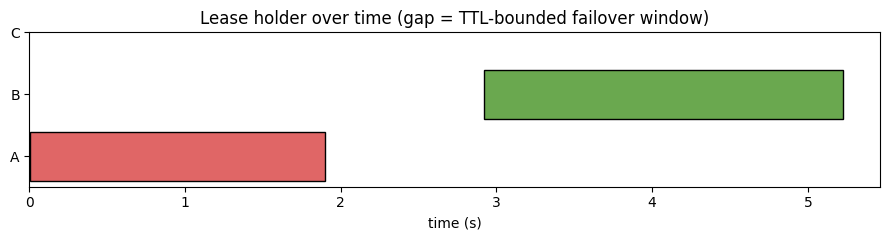

In [4]:
import matplotlib.pyplot as plt

# Derive leadership intervals from events.
names = ['A', 'B', 'C']
intervals = {n: [] for n in names}
active = {n: None for n in names}

for t, who, st in events:
    if st.startswith('leader'):
        active[who] = t
    elif st in ('crash', 'lost', 'stop') and active[who] is not None:
        intervals[who].append((active[who], t))
        active[who] = None

# Close any still-open interval at the end of the sim.
end_t = events[-1][0] if events else 0
for n in names:
    if active[n] is not None:
        intervals[n].append((active[n], end_t))

fig, ax = plt.subplots(figsize=(9, 2.5))
colors = {'A': '#e06666', 'B': '#6aa84f', 'C': '#3c78d8'}
for i, n in enumerate(names):
    for (s, e) in intervals[n]:
        ax.barh(i, e - s, left=s, color=colors[n], edgecolor='black')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel('time (s)')
ax.set_title('Lease holder over time (gap = TTL-bounded failover window)')
ax.set_xlim(0, end_t + 0.2)
plt.tight_layout()
plt.show()


## 
1. **A acquired first** (fencing token = 1) and started its renew loop.
2. After ~1.5s, A **stopped renewing** (simulated crash).
3. For up to `TTL` seconds, nobody could take  the lease was still "valid" from the system's point of view. **This is the price of not having a human say 'A is dead'.**over 
4. As soon as `expires_at` passed, B (or C) successfully `acquire`d with a **new fencing token = 2**.

### 
A zombie leader (e.g., A unpaused after a long GC pause) might still *think* it's the leader and send writes to a database. The database should reject any write whose fencing token is **less than the highest token it has seen**. Without this, A and B could both write "I am the leader!" causing **split-brain**. See the `split-brain-and-fencing` lab for a deeper dive.

### 
| TTL | Pros | Cons |
|---|---|---|
| Short (e.g. 1s) | fast failover | lots of renew traffic; spurious expirations on GC/network hiccups |
| Long (e.g. 30s) | cheap; tolerant of hiccups | slow failover; more dead time |

Rule of thumb in production (etcd, k8s):
- ` TTL / 3`interval 
- `TTL >> (max GC pause + max network RTT + clock skew budget)`

### 
- **Kubernetes controller-manager /  leader election via a `Lease` resource in the API server (kube-system/kube-scheduler). Default TTL 15s, renew every 10s.scheduler** 
- ** `Lease` API with TTL + `KeepAlive` stream (auto-renewal from the client library).etcd** 
- ** ephemeral nodes tied to the client session TTL.ZooKeeper** 
- ** sessions with a TTL; services attach locks to sessions.Consul** 
- ** `SET key val NX PX <ttl>` + periodic `SET ... XX PX <ttl>` (see Redlock).Redis** 
